In [1]:
from google.colab import drive

In [4]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/data.csv', encoding='ISO-8859-1')

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove negative quantity (returns)
df = df[df['Quantity'] > 0]

# Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create time features
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month

In [6]:
# Total Revenue
df['Revenue'].sum()

np.float64(8911407.904)

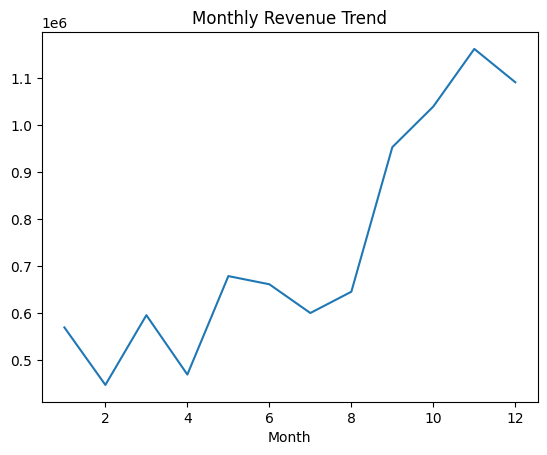

In [7]:
# Monthly Revenue Trend
import matplotlib.pyplot as plt

monthly_revenue = df.groupby('Month')['Revenue'].sum()

monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.show()

In [8]:
# Revenue by Country
df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

,Revenue
Country,
United Kingdom,7308391.554
Netherlands,285446.340
EIRE,265545.900
Germany,228867.140
France,209024.050
Australia,138521.310
Spain,61577.110
Switzerland,56443.950
Belgium,41196.340


In [9]:
# Top Customers
df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

,Revenue
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194550.79
16446.0,168472.50
14911.0,143825.06
12415.0,124914.53
14156.0,117379.63
17511.0,91062.38
16029.0,81024.84


In [10]:
# Top Products
df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

,Revenue
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142592.95
WHITE HANGING HEART T-LIGHT HOLDER,100448.15
JUMBO BAG RED RETROSPOT,85220.78
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68844.33
ASSORTED COLOUR BIRD ORNAMENT,56580.34
Manual,53779.93


In [11]:
# Repeat Customers
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()

repeat_customers = customer_orders[customer_orders > 1].count()

In [12]:
# Customer Segmentation
df.groupby('CustomerID')['Revenue'].sum().describe()

,Revenue
count,4339.000000
mean,2053.793018
std,8988.248381
min,0.000000
25%,307.245000
50%,674.450000
75%,1661.640000
max,280206.020000


In [13]:
# Total Revenue & Overview
print("Total Revenue:", df['Revenue'].sum())
print("Total Transactions:", df['InvoiceNo'].nunique())
print("Total Customers:", df['CustomerID'].nunique())

Total Revenue: 8911407.904
Total Transactions: 18536
Total Customers: 4339


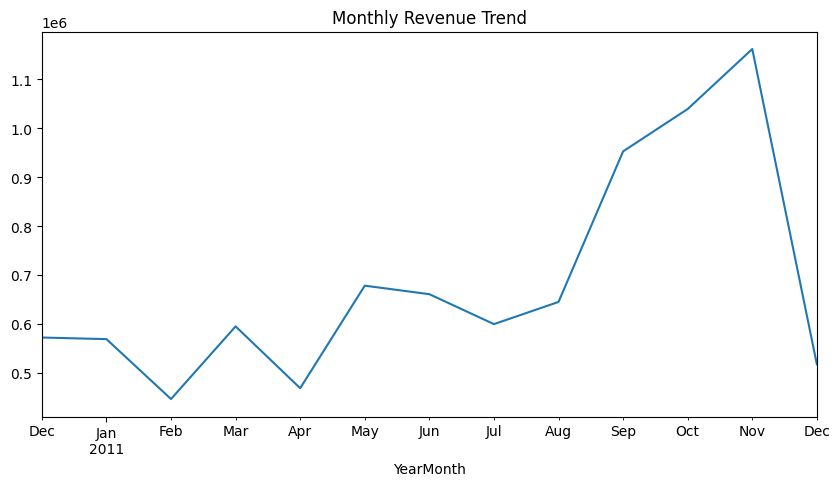

In [14]:
# Monthly Revenue Trend (Proper Way)
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('YearMonth')['Revenue'].sum()

monthly_revenue.plot(figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.show()

In [15]:
# Country-Level Analysis
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

country_revenue.head(10)

,Revenue
Country,
United Kingdom,7308391.554
Netherlands,285446.340
EIRE,265545.900
Germany,228867.140
France,209024.050
Australia,138521.310
Spain,61577.110
Switzerland,56443.950
Belgium,41196.340


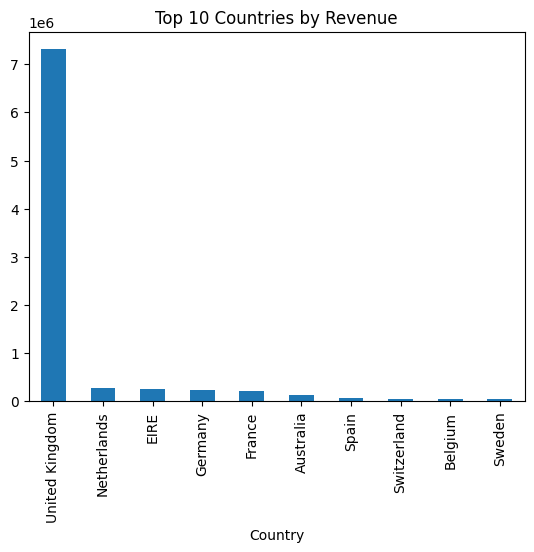

In [16]:
# Advanced:
country_revenue.head(10).plot(kind='bar')
plt.title("Top 10 Countries by Revenue")
plt.show()

In [17]:
# Top Customers
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)

top_customers.head(10)

,Revenue
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194550.79
16446.0,168472.50
14911.0,143825.06
12415.0,124914.53
14156.0,117379.63
17511.0,91062.38
16029.0,81024.84


In [18]:
# Contribution Analysis
top_10_revenue = top_customers.head(10).sum()
total_revenue = df['Revenue'].sum()

print("Top 10 customers contribution:", (top_10_revenue/total_revenue)*100)

Top 10 customers contribution: 17.261881248972173


In [19]:
# Top Products
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False)

top_products.head(10)

,Revenue
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142592.95
WHITE HANGING HEART T-LIGHT HOLDER,100448.15
JUMBO BAG RED RETROSPOT,85220.78
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68844.33
ASSORTED COLOUR BIRD ORNAMENT,56580.34
Manual,53779.93


In [20]:
# Low Performing Products
top_products.tail(10)

,Revenue
Description,
PACK 4 FLOWER/BUTTERFLY PATCHES,1.250
60 GOLD AND SILVER FAIRY CAKE CASES,1.100
CAT WITH SUNGLASSES BLANK CARD,0.950
HAPPY BIRTHDAY CARD TEDDY/CAKE,0.950
PINK CRYSTAL GUITAR PHONE CHARM,0.850
PURPLE FRANGIPANI HAIRCLIP,0.850
VINTAGE BLUE TINSEL REEL,0.840
SET 12 COLOURING PENCILS DOILEY,0.650
HEN HOUSE W CHICK IN NEST,0.420


In [21]:
# Repeat Customers
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()

repeat_customers = customer_orders[customer_orders > 1].count()
total_customers = df['CustomerID'].nunique()

print("Repeat Customer %:", (repeat_customers/total_customers)*100)

Repeat Customer %: 65.56810324959667


In [22]:
# Identify Returns
returns = df[df['Quantity'] < 0]

In [23]:
# Impact of Returns
returns['Revenue'] = returns['Quantity'] * returns['UnitPrice']

returns['Revenue'].sum()

np.float64(0.0)